# 06 `fpos` Vs `fmiss`: XAI And Target Asymmetry

This notebook confronts the two targets directly. The goal is not only to show that their winners differ, but to show why the thesis treats them as different scientific problems.

**Questions answered here**
- Which features dominate the best `fpos` model?
- How do family-level behaviors differ between the best `fpos` and best `fmiss` lines?
- Where is the strongest evidence that the two targets should not share one final recipe?


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def _find_thesis_root():
    cwd = Path.cwd().resolve()
    direct = [cwd, *cwd.parents]
    nested = [candidate / "thesis" for candidate in direct]
    for candidate in [*direct, *nested]:
        if (candidate / "THESIS_BLUEPRINT.md").exists() and (candidate / "src" / "qc_thesis" / "__init__.py").exists():
            return candidate
    raise FileNotFoundError("Could not find thesis root from notebook session")

ROOT = _find_thesis_root()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from qc_thesis import *

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
apply_thesis_style()

fig_dir, table_dir = notebook_output_dirs("06_fpos_vs_fmiss_xai")
shap_df = load_fpos_shap_importance()
shap_group_df = build_shap_group_summary()
fpos_family = build_family_summary("fpos_waveform_winner", "fpos", "recording_disjoint_main")
fmiss_family = build_family_summary("fmiss_reduced_latent", "fmiss", "recording_disjoint_main")
asymmetry = build_target_asymmetry_table()
fpos_progress = build_benchmark_progress_table("fpos")
fmiss_progress = build_benchmark_progress_table("fmiss")


## 1. What drives the best `fpos` model?

The SHAP summary is useful because it tells us whether the winner is a black box or a structured correction model. The answer from earlier analysis was: a strong transferred prior plus waveform/amplitude/ISI corrections.


,feature,mean_abs_shap
0,source_pred,0.031848
1,amp_bin_spread_ratio_recording_std,0.023848
2,amp_bin_cv_mean_recording_pct,0.023127
3,si_isi_violations_count,0.022218
4,si_amplitude_cv_median,0.021904
5,si_amplitude_cv_median_recording_pct,0.009627
6,amp_std_recording_pct,0.008788
7,wf_bin_13,0.007864
8,amp_bimodality,0.007628
9,amp_bin_cv_mean_recording_pct_recording_delta,0.007464


,feature_group,mean_abs_shap,feature_count
0,recording_context,0.188408,492
1,spikeinterface_qc,0.092832,20
2,waveform,0.034117,58
3,source_transfer,0.031848,1
4,acg,0.027643,40
5,other,0.021570,32
6,amplitude,0.016098,19


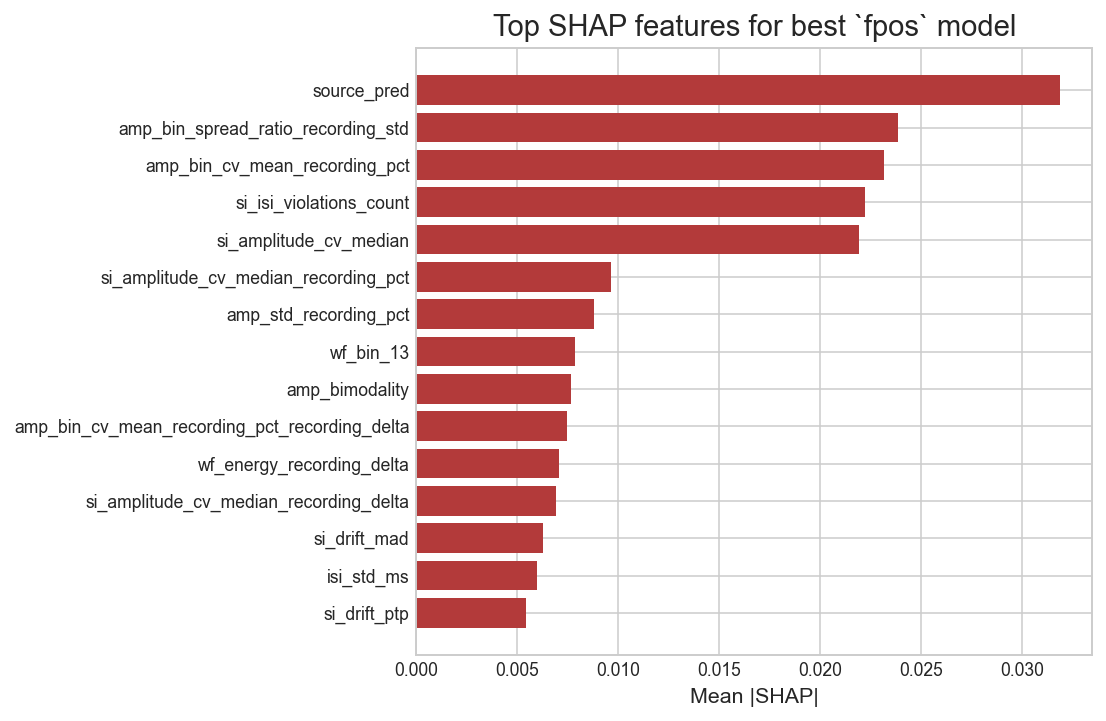

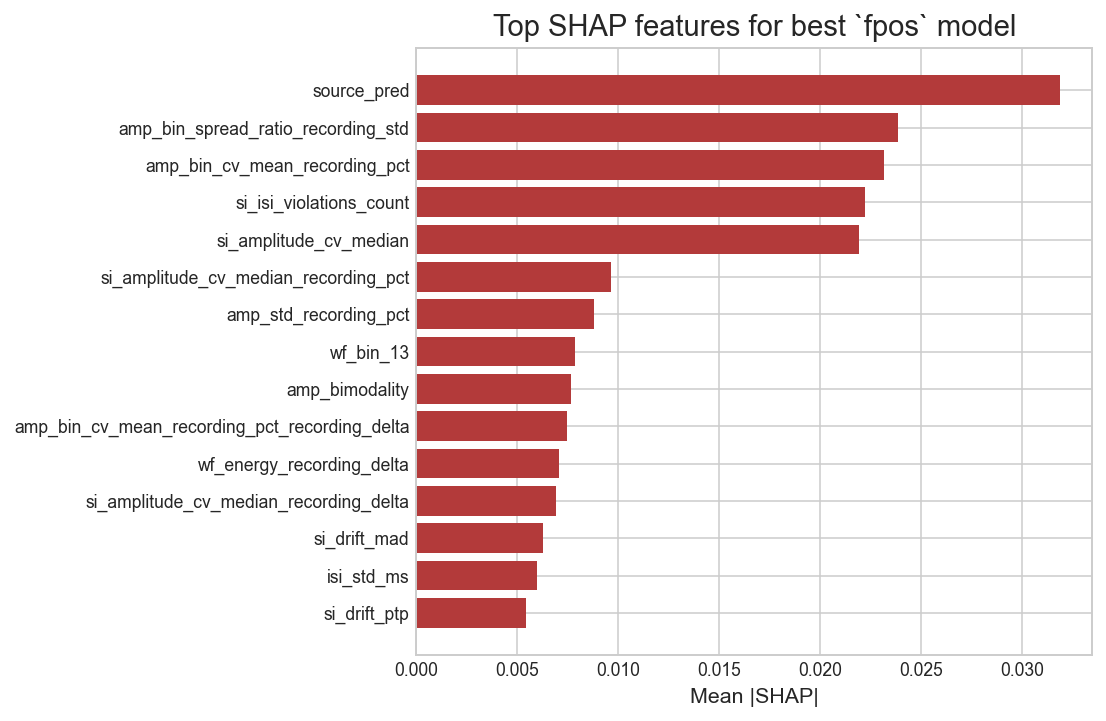

In [2]:
display(shap_df.head(20))
display(shap_group_df)
save_table(shap_df, table_dir, "fpos_shap_importance")
save_table(shap_group_df, table_dir, "fpos_shap_group_summary")
fig, _ = plot_fpos_shap_top(shap_df, top_n=15)
save_figure(fig, fig_dir, "fpos_shap_top")
fig


## 2. Family behavior side by side

The family tables below make the asymmetry concrete. The question is not only which model is better overall, but which families reward or punish each target differently.


In [3]:
display(fpos_family)
display(fmiss_family)
display(asymmetry)
save_table(fpos_family, table_dir, "fpos_family_summary")
save_table(fmiss_family, table_dir, "fmiss_family_summary")
save_table(asymmetry, table_dir, "fpos_vs_fmiss_family_comparison")


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fpos_waveform_winner,Waveform winner,PAIRED_BOYDEN,21,0.045268,0.057068,0.589369,-0.013778
1,fpos_waveform_winner,Waveform winner,PAIRED_CRCNS_HC1,9,0.154243,0.230553,0.371286,-0.090469
2,fpos_waveform_winner,Waveform winner,PAIRED_ENGLISH,44,0.164310,0.211700,0.476975,-0.043952
3,fpos_waveform_winner,Waveform winner,PAIRED_KAMPFF,6,0.106065,0.125558,0.685079,-0.106065
4,fpos_waveform_winner,Waveform winner,PAIRED_MEA64C_YGER,20,0.059607,0.081370,0.504386,-0.052010


,recipe_id,label,study_set,row_count,mae,rmse,r2,bias
0,fmiss_reduced_latent,Reduced-latent winner,PAIRED_BOYDEN,21,0.114989,0.154447,0.665237,-0.019304
1,fmiss_reduced_latent,Reduced-latent winner,PAIRED_CRCNS_HC1,9,0.128021,0.177694,-0.182062,-0.006746
2,fmiss_reduced_latent,Reduced-latent winner,PAIRED_ENGLISH,44,0.230393,0.271381,0.228761,-0.044655
3,fmiss_reduced_latent,Reduced-latent winner,PAIRED_KAMPFF,6,0.103353,0.110528,-1.474106,0.064757
4,fmiss_reduced_latent,Reduced-latent winner,PAIRED_MEA64C_YGER,20,0.064908,0.105413,0.857735,-0.022698


,study_set,fpos_r2,fpos_mae,fpos_bias,fmiss_r2,fmiss_mae,fmiss_bias
0,PAIRED_BOYDEN,0.589369,0.045268,-0.013778,0.665237,0.114989,-0.019304
1,PAIRED_CRCNS_HC1,0.371286,0.154243,-0.090469,-0.182062,0.128021,-0.006746
2,PAIRED_ENGLISH,0.476975,0.164310,-0.043952,0.228761,0.230393,-0.044655
3,PAIRED_KAMPFF,0.685079,0.106065,-0.106065,-1.474106,0.103353,0.064757
4,PAIRED_MEA64C_YGER,0.504386,0.059607,-0.052010,0.857735,0.064908,-0.022698


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/06_fpos_vs_fmiss_xai/fpos_vs_fmiss_family_comparison.csv')

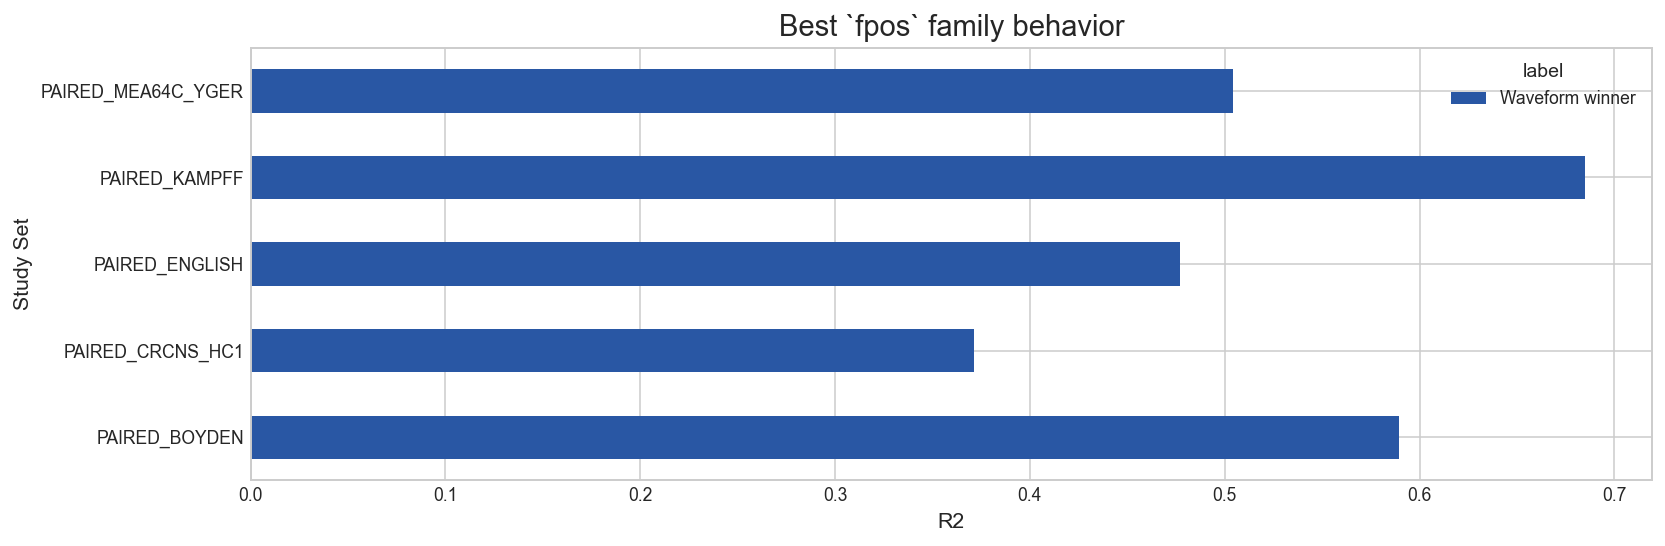

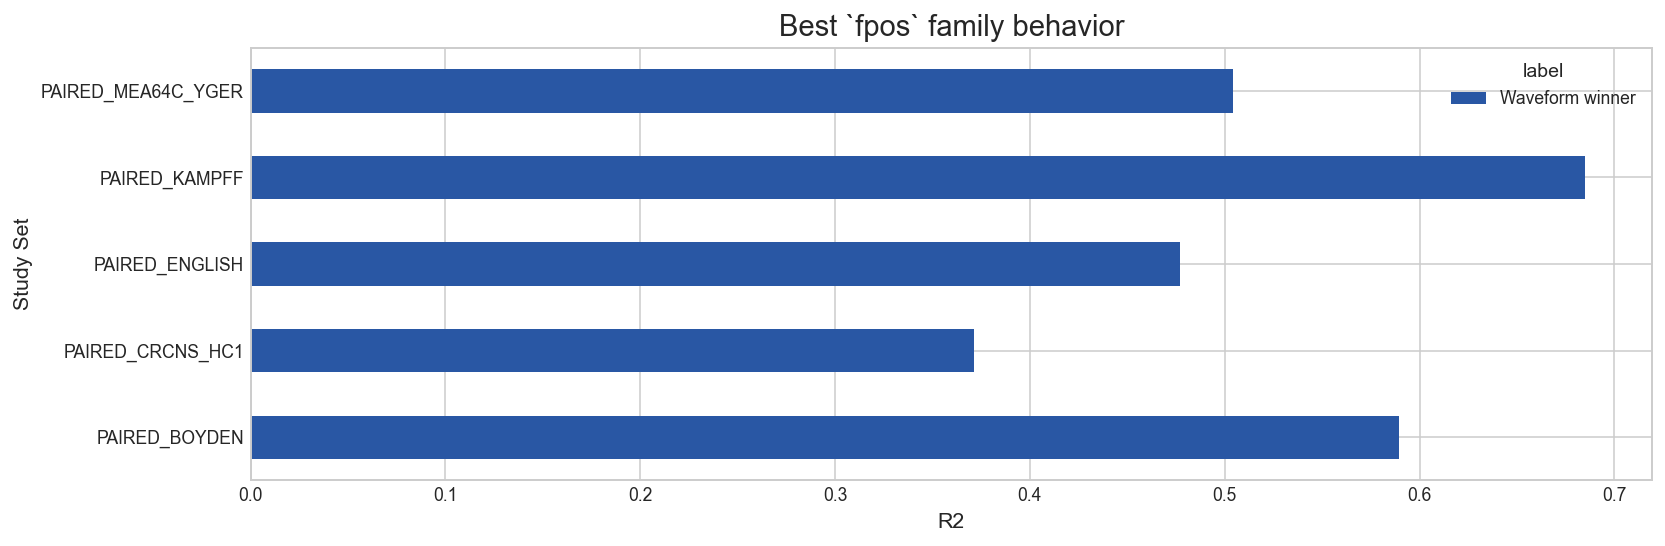

In [4]:
fig, _, _ = plot_group_metric(fpos_family, group_col="study_set", metric="r2", title="Best `fpos` family behavior")
save_figure(fig, fig_dir, "fpos_family_behavior")
fig


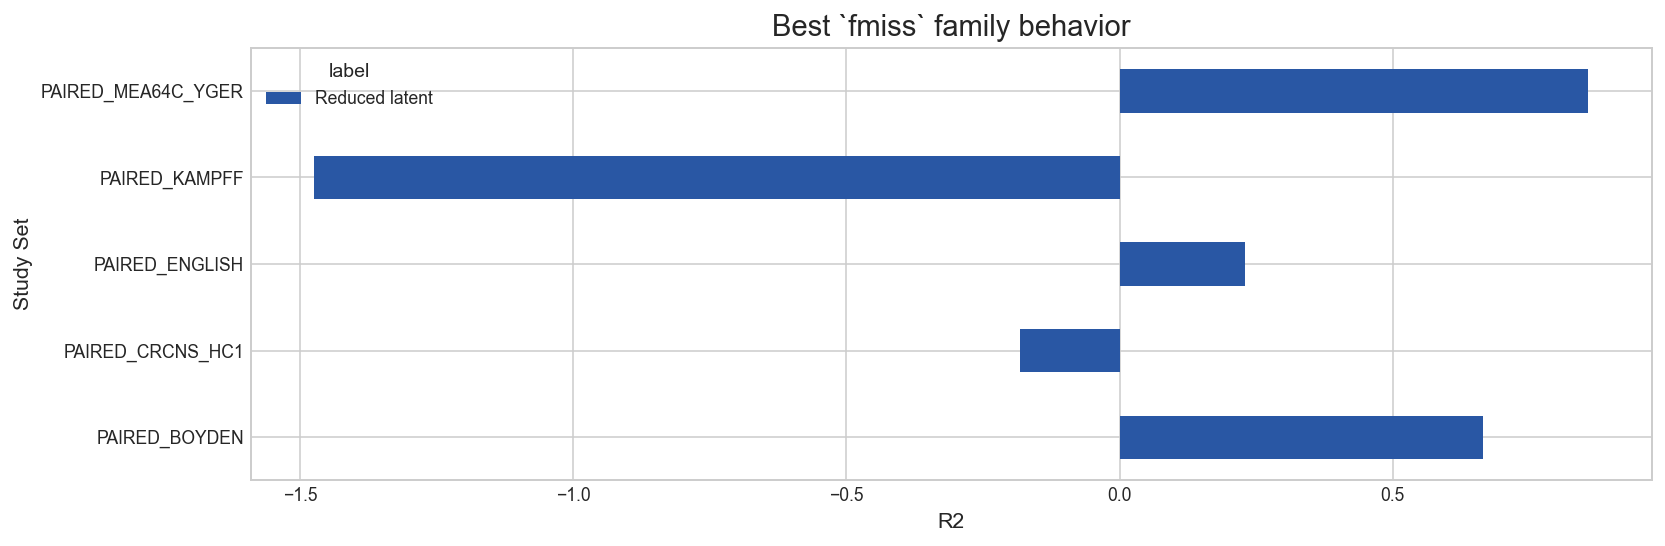

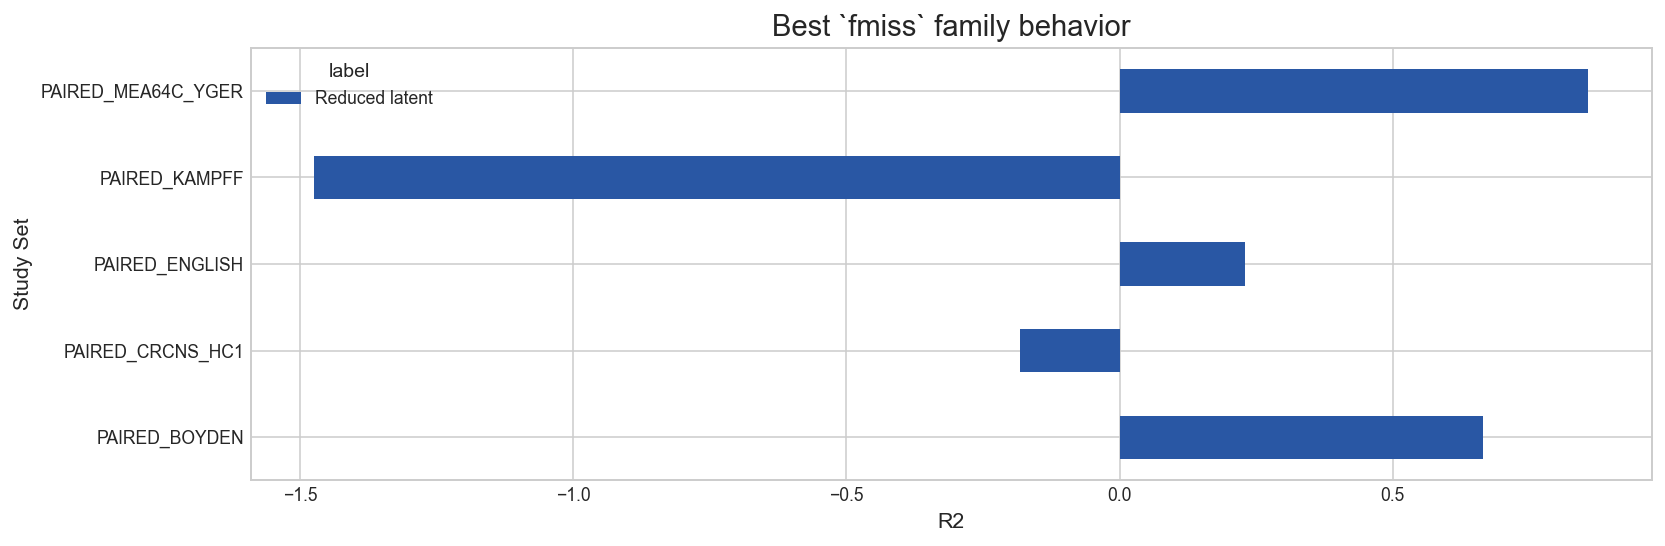

In [5]:
fig, _, _ = plot_group_metric(fmiss_family, group_col="study_set", metric="r2", title="Best `fmiss` family behavior")
save_figure(fig, fig_dir, "fmiss_family_behavior")
fig


,study_set,fpos_r2,fpos_mae,fpos_bias,fmiss_r2,fmiss_mae,fmiss_bias,r2_gap_fpos_minus_fmiss
3,PAIRED_KAMPFF,0.685079,0.106065,-0.106065,-1.474106,0.103353,0.064757,2.159185
1,PAIRED_CRCNS_HC1,0.371286,0.154243,-0.090469,-0.182062,0.128021,-0.006746,0.553348
2,PAIRED_ENGLISH,0.476975,0.164310,-0.043952,0.228761,0.230393,-0.044655,0.248213
0,PAIRED_BOYDEN,0.589369,0.045268,-0.013778,0.665237,0.114989,-0.019304,-0.075868
4,PAIRED_MEA64C_YGER,0.504386,0.059607,-0.052010,0.857735,0.064908,-0.022698,-0.353349


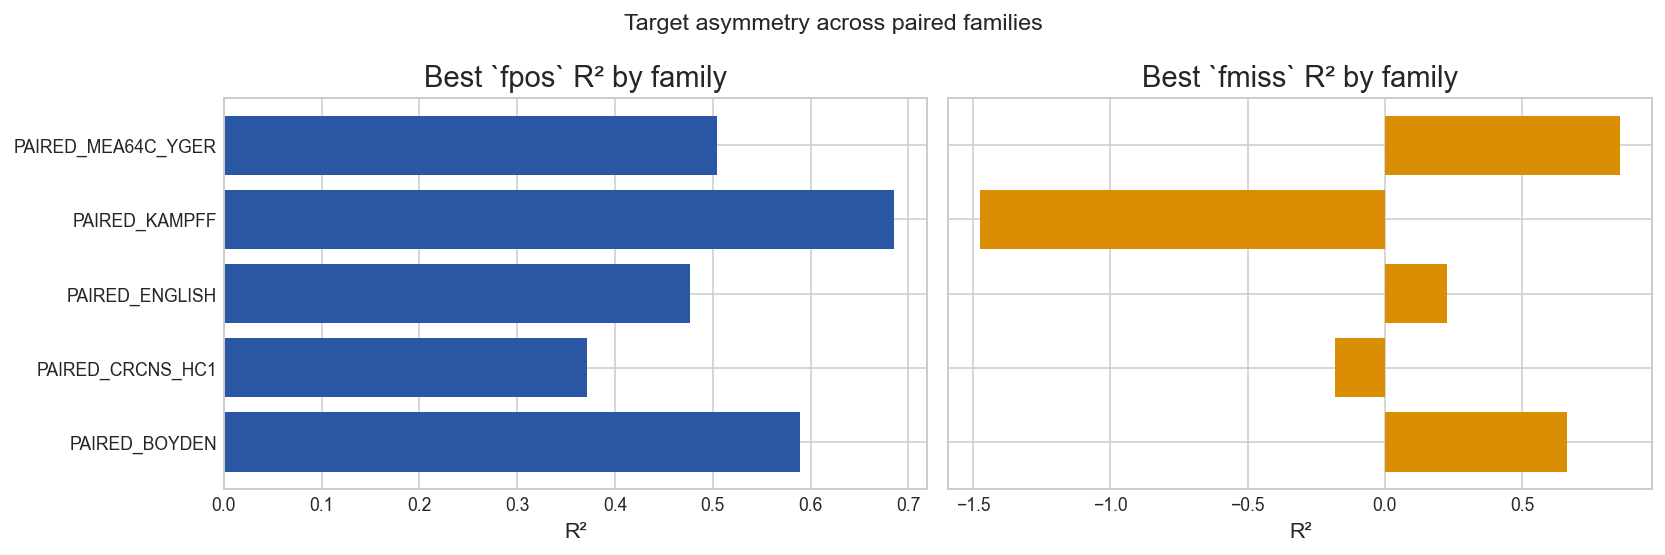

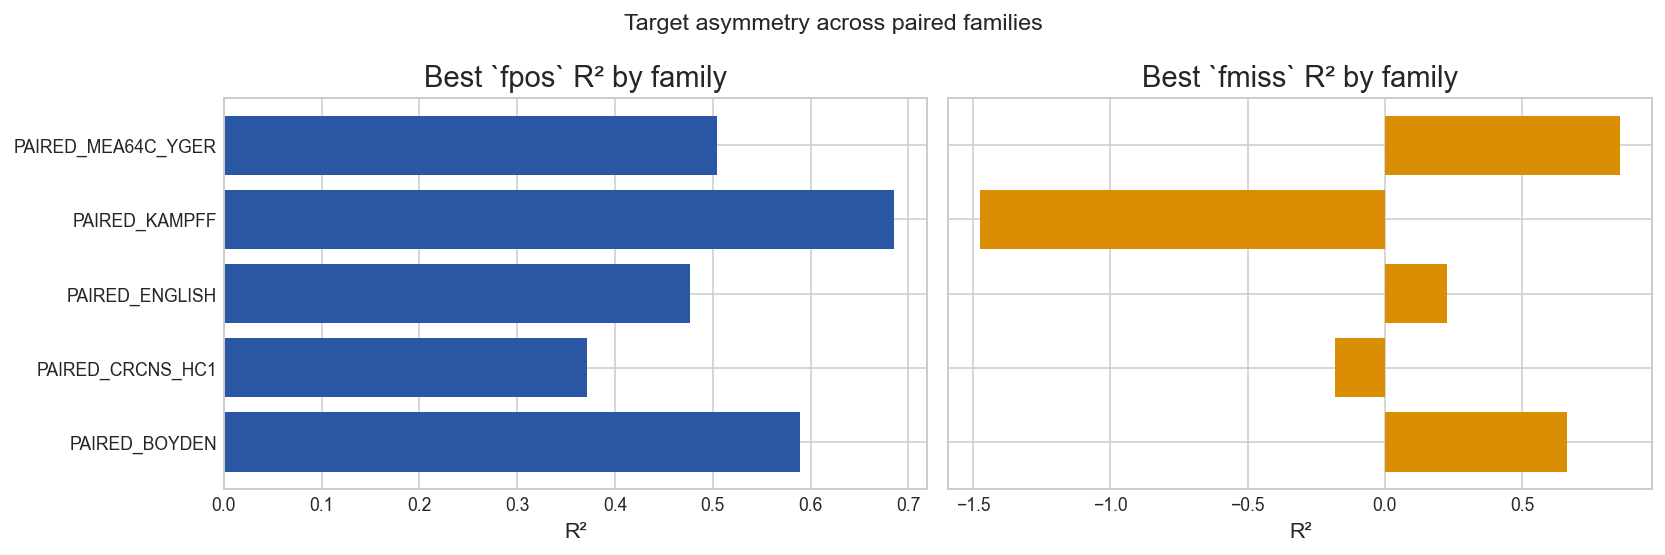

In [6]:
asymmetry["r2_gap_fpos_minus_fmiss"] = asymmetry["fpos_r2"] - asymmetry["fmiss_r2"]
display(asymmetry.sort_values("r2_gap_fpos_minus_fmiss", ascending=False))
fig, _ = plot_target_asymmetry(asymmetry)
save_figure(fig, fig_dir, "target_asymmetry_combined")
fig


## 3. Benchmark-level asymmetry

This table compresses the whole thesis finding into one summary: `fpos` gained much more from the later target-aware structure than `fmiss` did.


In [7]:
basic_fpos = fpos_progress.loc[fpos_progress["recipe_id"] == "fpos_hybrid_plus_paired"].iloc[0]
final_fpos = fpos_progress.sort_values("r2", ascending=False).iloc[0]
basic_fmiss = fmiss_progress.loc[fmiss_progress["recipe_id"] == "fmiss_hybrid_residual"].iloc[0]
final_fmiss = fmiss_progress.sort_values("r2", ascending=False).iloc[0]
target_story = pd.DataFrame([
    {"target": "fpos", "basic_transfer_r2": basic_fpos["r2"], "final_r2": final_fpos["r2"], "gain_r2": final_fpos["r2"] - basic_fpos["r2"]},
    {"target": "fmiss", "basic_transfer_r2": basic_fmiss["r2"], "final_r2": final_fmiss["r2"], "gain_r2": final_fmiss["r2"] - basic_fmiss["r2"]},
])
display(target_story)
save_table(target_story, table_dir, "target_progress_summary")


,target,basic_transfer_r2,final_r2,gain_r2
0,fpos,0.358539,0.547852,0.189313
1,fmiss,0.212802,0.484977,0.272175


PosixPath('/Users/paulruiz/Documents/Predicting_Good_Units/thesis/tables/06_fpos_vs_fmiss_xai/target_progress_summary.csv')

In [8]:
display(Markdown(
    """
## Key takeaways

- The best `fpos` model is heavily shaped by transferred prior information plus waveform/amplitude corrections.
- The best `fmiss` model is more conservative and context-first.
- Family-level asymmetry is not noise; it is evidence that `fpos` and `fmiss` respond to different kinds of transfer signal.
- This notebook is the strongest support for using separate deployment models for the two targets.
"""
))



## Key takeaways

- The best `fpos` model is heavily shaped by transferred prior information plus waveform/amplitude corrections.
- The best `fmiss` model is more conservative and context-first.
- Family-level asymmetry is not noise; it is evidence that `fpos` and `fmiss` respond to different kinds of transfer signal.
- This notebook is the strongest support for using separate deployment models for the two targets.
